# Sprint Ford — IA & ML
## Parte 1: Entendimento do Negócio e Preparação dos Dados
### Base 1 — Histórico Completo de Clientes

### Equipe

| Nome | RM |
|---|---|
| *Arthur Bobadilla Franchi* | RM 555056 |
| *Luan Orlandelli Ramos* | RM 554747 |
| *Jorge Luiz* | RM 554418 |

---

> **Objetivo:** Contextualizar o problema de retenção, entender a estrutura e qualidade da Base 1, tratar inconsistências e preparar os dados para a etapa de segmentação comportamental (Etapa 2).


## 1. Contexto de Negócio

### Por que retenção na rede oficial importa?

A Ford opera um modelo de receita em que o veículo representa apenas o ponto de entrada do relacionamento com o cliente. O ciclo de vida completo revisões periódicas, recall, troca de peças, manutenções preventivas e corretivas é a principal fonte de receita recorrente da rede autorizada e, igualmente, o principal canal de fidelização para recompra futura.

**Perder o cliente para oficinas externas significa:**
- Redução direta de receita de serviços (alta margem)
- Perda de controle sobre a experiência da marca
- Redução da probabilidade de recompra de um Ford no futuro
- Impossibilidade de intervir proativamente em insatisfações

### O desafio

No momento da compra, a concessionária **não sabe** qual será o comportamento futuro do cliente. Ela apenas dispõe das informações coletadas na venda. Isso cria um problema de **assimetria de informação** que este projeto resolve em duas etapas:

1. **Segmentação (não supervisionada):** com o histórico completo, descobrimos quais perfis comportamentais realmente existem nos dados.
2. **Classificação (supervisionada):** com apenas os dados do momento da compra, prevemos o perfil de novos clientes para que a concessionária possa agir desde o início.

> **Anti Data Leakage:** Variáveis comportamentais pós-venda (`revisões`, `churn`, `gasto`, `satisfação`, etc.) são exclusivas da Etapa 1. Jamais serão utilizadas na Etapa 2 (classificação).


## 2. Setup e Carregamento dos Dados

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

uploaded = files.upload()
df = pd.read_csv('ford_clientes_historico_completo.csv')
print(f'Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')


Saving ford_clientes_historico_completo.csv to ford_clientes_historico_completo.csv
Dataset carregado: 500,000 linhas × 37 colunas


## 3. Mapeamento e Classificação das Variáveis

A Base 1 contém 37 colunas distribuídas em três grupos funcionais distintos.
Essa distinção é crítica para evitar data leakage na Etapa 2


In [ ]:
# Classificação das variáveis
ID_COLS = ['cliente_id']
LABEL_COL = ['perfil_latente']

PURCHASE_VARS = [
    # Perfil do cliente
    'idade', 'renda_mensal', 'score_credito', 'regiao', 'uso_principal',
    'km_estimado_mes', 'teve_ford_antes', 'distancia_concessionaria_km',
    # Negociação / veículo
    'canal_compra', 'categoria_veiculo', 'modelo_veiculo', 'valor_veiculo',
    'usou_troca', 'entrada_pct', 'prazo_financiamento_meses', 'compra_a_vista',
    'prestacao_renda_ratio',
    # Sinais iniciais / proxies do momento da venda
    'garantia_estendida', 'plano_manutencao', 'aceitou_marketing',
    'sensibilidade_preco_inicial', 'organizacao_proxy', 'tempo_decisao_dias'
]

BEHAVIORAL_VARS = [
    'fez_primeira_revisao_rede', 'meses_ate_primeira_revisao', 'perdeu_primeira_revisao',
    'voltou_tarde_revoltado', 'trouxe_oleo_externo', 'pede_desconto_revisao',
    'sensibilidade_desconto_pos', 'qtde_revisoes_24m', 'share_revisoes_rede_24m',
    'gasto_manutencao_rede_24m', 'satisfacao_marca_24m', 'churn_rede_24m'
]

summary = pd.DataFrame({
    'Grupo': ['ID / Chave'] + ['Label (Ground Truth)'] + ['Momento da Compra'] * len(PURCHASE_VARS) + ['Comportamental Pós-Venda'] * len(BEHAVIORAL_VARS),
    'Variável': ID_COLS + LABEL_COL + PURCHASE_VARS + BEHAVIORAL_VARS,
    'Uso permitido na Etapa 2': ['Não'] + ['Não'] + ['Sim'] * len(PURCHASE_VARS) + ['⚠️ PROIBIDO'] * len(BEHAVIORAL_VARS)
})
print(summary.to_string(index=False))


                   Grupo                    Variável Uso permitido na Etapa 2
              ID / Chave                  cliente_id                      Não
    Label (Ground Truth)              perfil_latente                      Não
       Momento da Compra                       idade                      Sim
       Momento da Compra                renda_mensal                      Sim
       Momento da Compra               score_credito                      Sim
       Momento da Compra                      regiao                      Sim
       Momento da Compra               uso_principal                      Sim
       Momento da Compra             km_estimado_mes                      Sim
       Momento da Compra             teve_ford_antes                      Sim
       Momento da Compra distancia_concessionaria_km                      Sim
       Momento da Compra                canal_compra                      Sim
       Momento da Compra           categoria_veiculo            

## 4. Overview Estrutural do Dataset

In [ ]:
# Tipos e nulos
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info_df[info_df['nulls'] > 0].sort_values('null_pct', ascending=False).to_string())
print(f'\nTotal de células nulas: {df.isnull().sum().sum():,} ({df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100:.2f}%)')


                               dtype  nulls  null_pct  unique
renda_mensal                 float64  12338     2.470  425800
score_credito                float64  10210     2.040     603
distancia_concessionaria_km  float64   8926     1.790    1548
satisfacao_marca_24m         float64   7473     1.490     101
tempo_decisao_dias           float64   5991     1.200      67
aceitou_marketing            float64   5054     1.010       2
share_revisoes_rede_24m      float64   4966     0.990    1001
idade                        float64   4890     0.980      68
gasto_manutencao_rede_24m    float64   3984     0.800  272285
teve_ford_antes              float64   3960     0.790       2
plano_manutencao             float64   3007     0.600       2
garantia_estendida           float64   2992     0.600       2

Total de células nulas: 73,791 (0.40%)


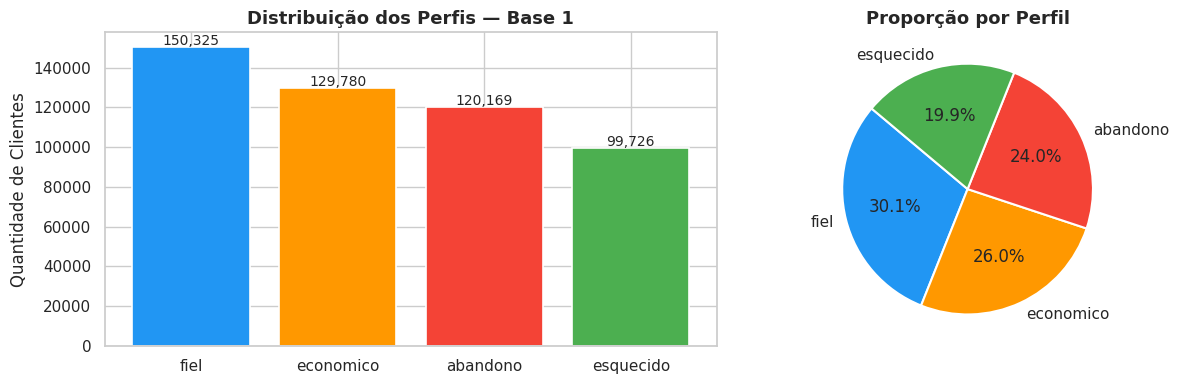

Distribuição:
 perfil_latente
fiel         150325
economico    129780
abandono     120169
esquecido     99726


In [ ]:
# Distribuição da variável de perfil
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['perfil_latente'].value_counts()
colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribuição dos Perfis — Base 1')
axes[0].set_ylabel('Quantidade de Clientes')
for i, (v, c) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, c + 1000, f'{c:,}', ha='center', fontsize=10)

pcts = df['perfil_latente'].value_counts(normalize=True) * 100
axes[1].pie(pcts.values, labels=pcts.index, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporção por Perfil')

plt.tight_layout()
plt.savefig('plot_profile_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print("Distribuição:\n", counts.to_string())


## 5. Análise Exploratória — Variáveis Numéricas

In [ ]:
# Variáveis do momento da compra
num_purchase = [v for v in PURCHASE_VARS if df[v].dtype in ['float64','int64']]
df[num_purchase].describe().round(2)


,idade,renda_mensal,score_credito,km_estimado_mes,teve_ford_antes,distancia_concessionaria_km,valor_veiculo,usou_troca,entrada_pct,prazo_financiamento_meses,compra_a_vista,prestacao_renda_ratio,garantia_estendida,plano_manutencao,aceitou_marketing,sensibilidade_preco_inicial,organizacao_proxy,tempo_decisao_dias
count,495110.000,487662.000,489790.000,500000.000,496040.000,491074.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,497008.000,496993.000,494946.000,500000.000,500000.000,494009.000
mean,41.640,11558.830,709.700,1647.730,0.350,21.030,141943.530,0.360,0.520,32.400,0.370,0.180,0.310,0.180,0.510,0.540,0.540,17.090
std,10.720,6367.940,76.340,605.030,0.480,17.510,62691.250,0.480,0.380,27.690,0.480,0.230,0.460,0.380,0.500,0.260,0.240,9.380
min,18.000,1800.000,333.000,200.000,0.000,0.500,55000.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,34.000,7194.220,659.000,1247.000,0.000,8.900,86320.400,0.000,0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.330,0.350,10.000
50%,42.000,10190.400,713.000,1611.000,0.000,16.100,133205.000,0.000,0.340,39.000,0.000,0.120,0.000,0.000,1.000,0.530,0.550,16.000
75%,49.000,14348.980,763.000,2008.000,1.000,27.800,192145.750,1.000,1.000,56.000,1.000,0.270,1.000,0.000,1.000,0.750,0.730,23.000
max,85.000,186610.770,980.000,11724.000,1.000,364.100,678148.850,1.000,1.000,84.000,1.000,2.500,1.000,1.000,1.000,1.000,1.000,70.000


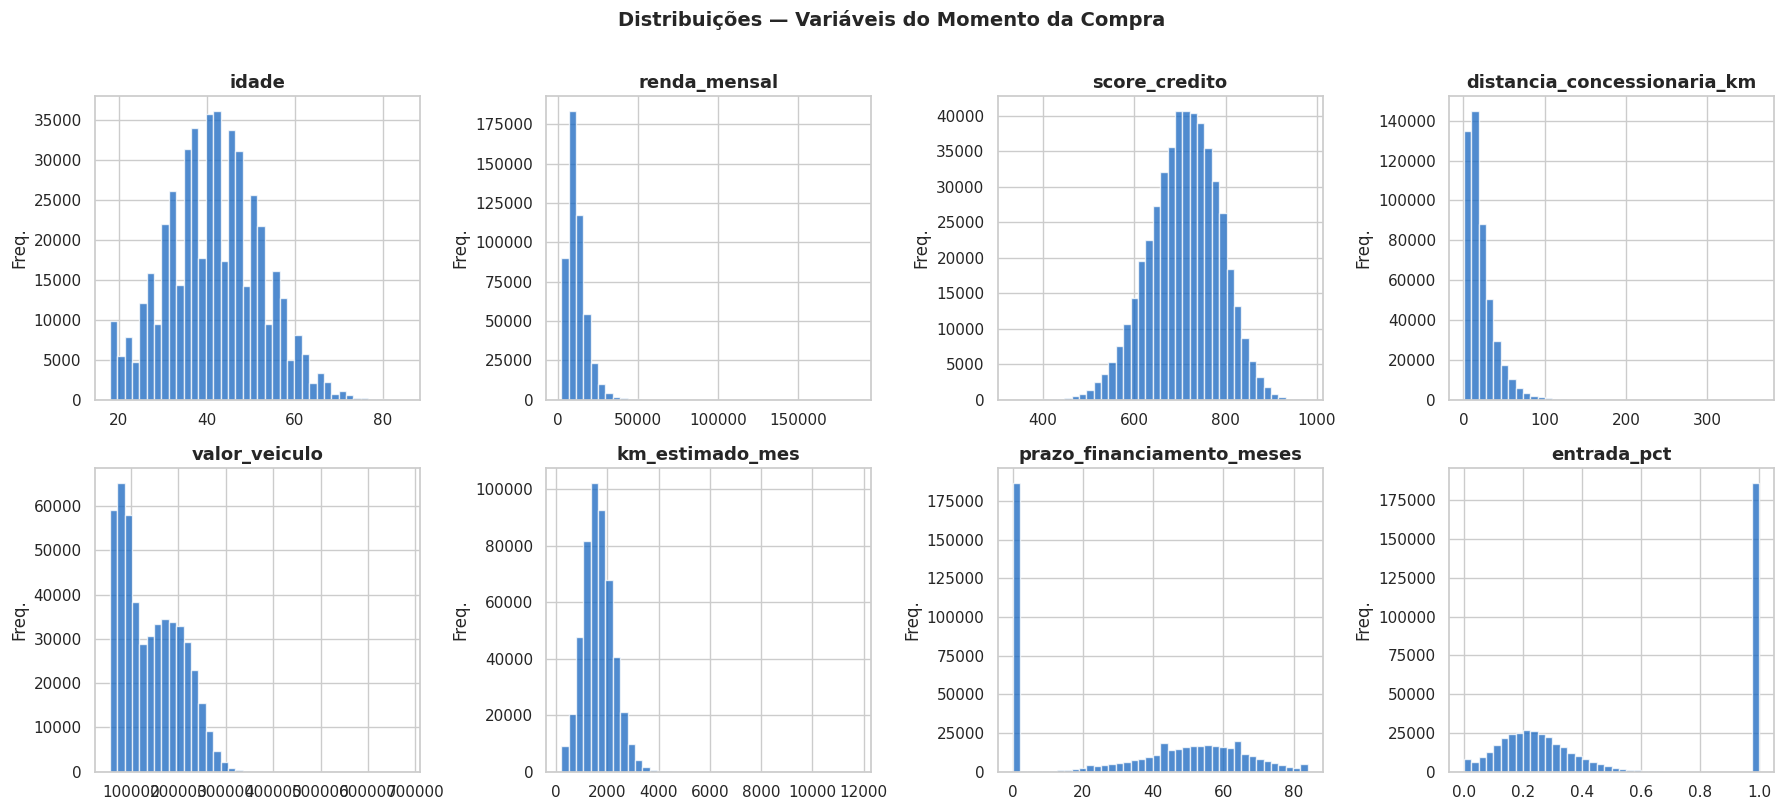

In [ ]:
# Distribuições das principais variáveis numéricas de compra
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

vars_to_plot = ['idade', 'renda_mensal', 'score_credito', 'distancia_concessionaria_km',
                'valor_veiculo', 'km_estimado_mes', 'prazo_financiamento_meses', 'entrada_pct']

for i, var in enumerate(vars_to_plot):
    axes[i].hist(df[var].dropna(), bins=40, color='#1565C0', alpha=0.75, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Freq.')

plt.suptitle('Distribuições — Variáveis do Momento da Compra', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_num_dist.png', dpi=110, bbox_inches='tight')
plt.show()


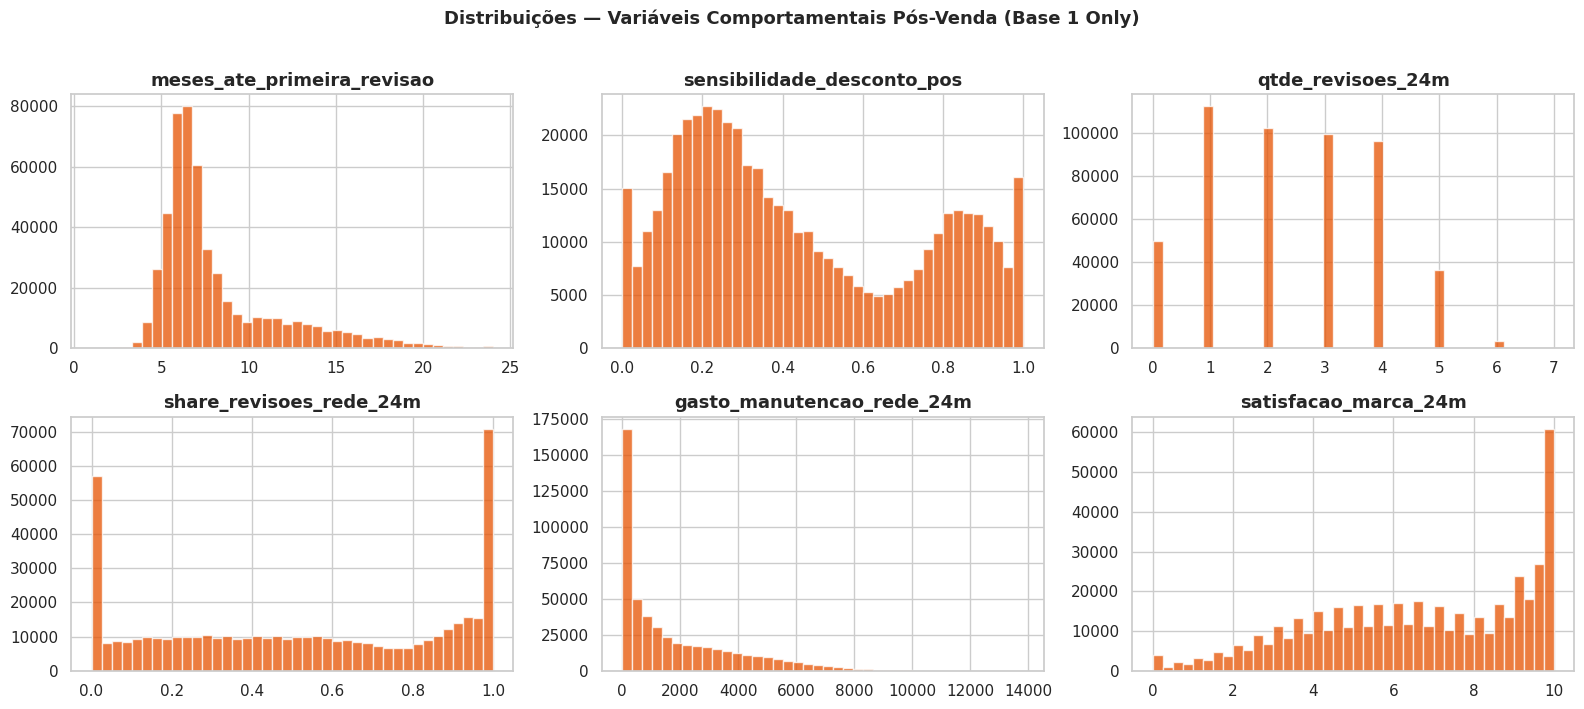

In [ ]:
# Distribuições das variáveis comportamentais pós-venda
behav_cont = ['meses_ate_primeira_revisao','sensibilidade_desconto_pos',
              'qtde_revisoes_24m','share_revisoes_rede_24m',
              'gasto_manutencao_rede_24m','satisfacao_marca_24m']

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for i, var in enumerate(behav_cont):
    axes[i].hist(df[var].dropna(), bins=40, color='#E65100', alpha=0.75, edgecolor='white')
    axes[i].set_title(var)
plt.suptitle('Distribuições — Variáveis Comportamentais Pós-Venda (Base 1 Only)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_behav_dist.png', dpi=110, bbox_inches='tight')
plt.show()


## 6. Análise Exploratória — Variáveis Categóricas

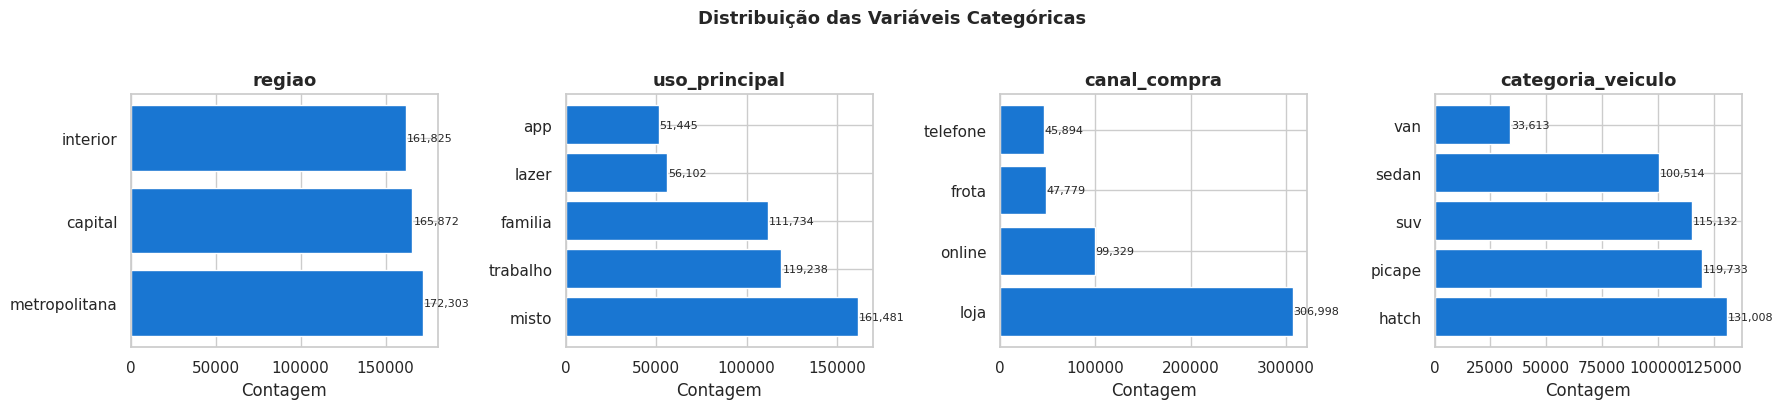

In [ ]:
cat_vars = ['regiao','uso_principal','canal_compra','categoria_veiculo']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, var in enumerate(cat_vars):
    vc = df[var].value_counts()
    axes[i].barh(vc.index, vc.values, color='#1976D2', edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('Contagem')
    for j, v in enumerate(vc.values):
        axes[i].text(v + 500, j, f'{v:,}', va='center', fontsize=8)

plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_cat_dist.png', dpi=110, bbox_inches='tight')
plt.show()


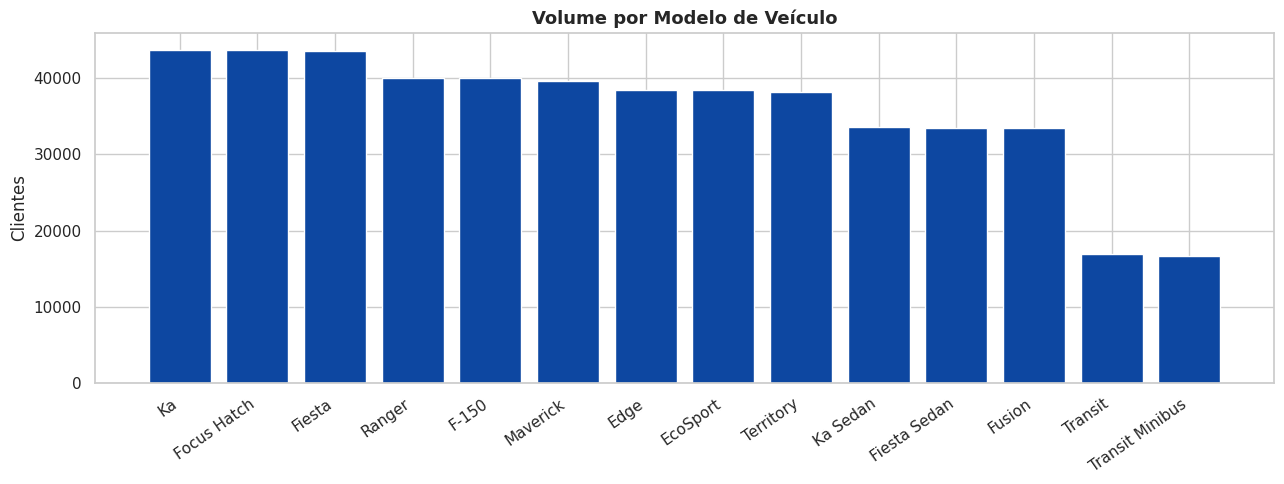

In [ ]:
# Modelo de veículo por categoria
fig, ax = plt.subplots(figsize=(13, 5))
model_counts = df['modelo_veiculo'].value_counts()
ax.bar(model_counts.index, model_counts.values, color='#0D47A1', edgecolor='white')
ax.set_xticklabels(model_counts.index, rotation=35, ha='right')
ax.set_title('Volume por Modelo de Veículo')
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.savefig('plot_models.png', dpi=110, bbox_inches='tight')
plt.show()


## 7. Análise por Perfil — Validação Exploratória das Hipóteses de Negócio

Antes de qualquer clusterização, verificamos se o `perfil_latente`
já apresenta separação estatística visível nas variáveis.


In [ ]:
# Médias comportamentais por perfil
behav_means = df.groupby('perfil_latente')[BEHAVIORAL_VARS].mean().round(3)
behav_means.style.background_gradient(cmap='RdYlGn', axis=0)


,fez_primeira_revisao_rede,meses_ate_primeira_revisao,perdeu_primeira_revisao,voltou_tarde_revoltado,trouxe_oleo_externo,pede_desconto_revisao,sensibilidade_desconto_pos,qtde_revisoes_24m,share_revisoes_rede_24m,gasto_manutencao_rede_24m,satisfacao_marca_24m,churn_rede_24m
perfil_latente,,,,,,,,,,,,
abandono,0.750000,7.395000,0.350000,0.021000,0.612000,0.281000,0.421000,1.194000,0.159000,151.022000,4.722000,0.275000
economico,0.869000,7.321000,0.320000,0.016000,0.220000,0.840000,0.856000,2.729000,0.568000,1455.878000,7.162000,0.103000
esquecido,0.291000,13.317000,0.909000,0.516000,0.091000,0.122000,0.301000,1.118000,0.297000,348.653000,3.631000,0.209000
fiel,0.982000,6.068000,0.048000,0.000000,0.010000,0.080000,0.181000,3.946000,0.931000,4271.662000,9.449000,0.024000


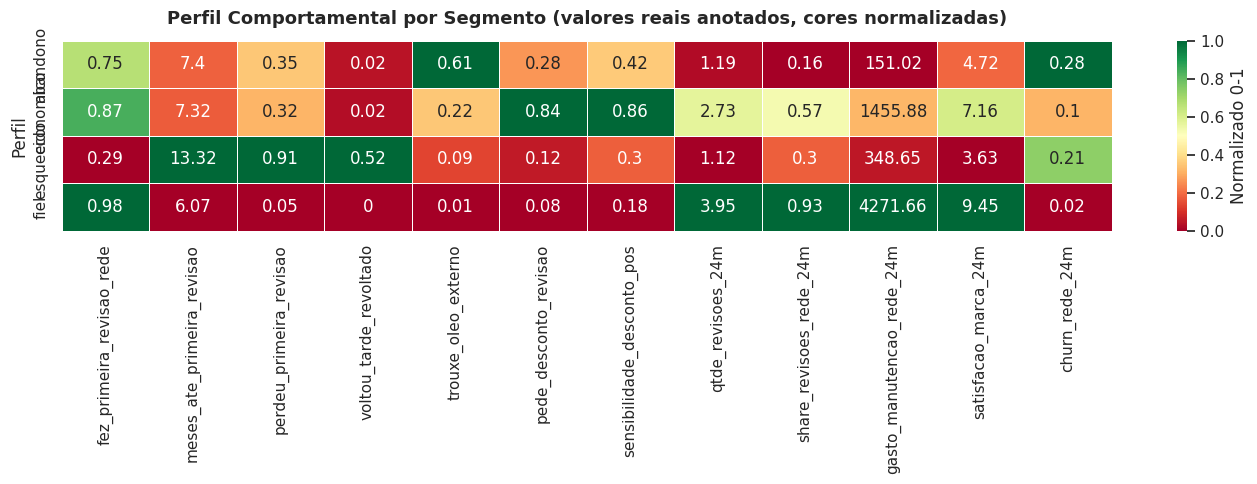

In [ ]:
# Heatmap comportamental por perfil
fig, ax = plt.subplots(figsize=(14, 5))
behav_norm = (behav_means - behav_means.min()) / (behav_means.max() - behav_means.min())
sns.heatmap(behav_norm, annot=behav_means.round(2), fmt='g', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalizado 0-1'})
ax.set_title('Perfil Comportamental por Segmento (valores reais anotados, cores normalizadas)', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Perfil')
plt.tight_layout()
plt.savefig('plot_heatmap_behav.png', dpi=120, bbox_inches='tight')
plt.show()


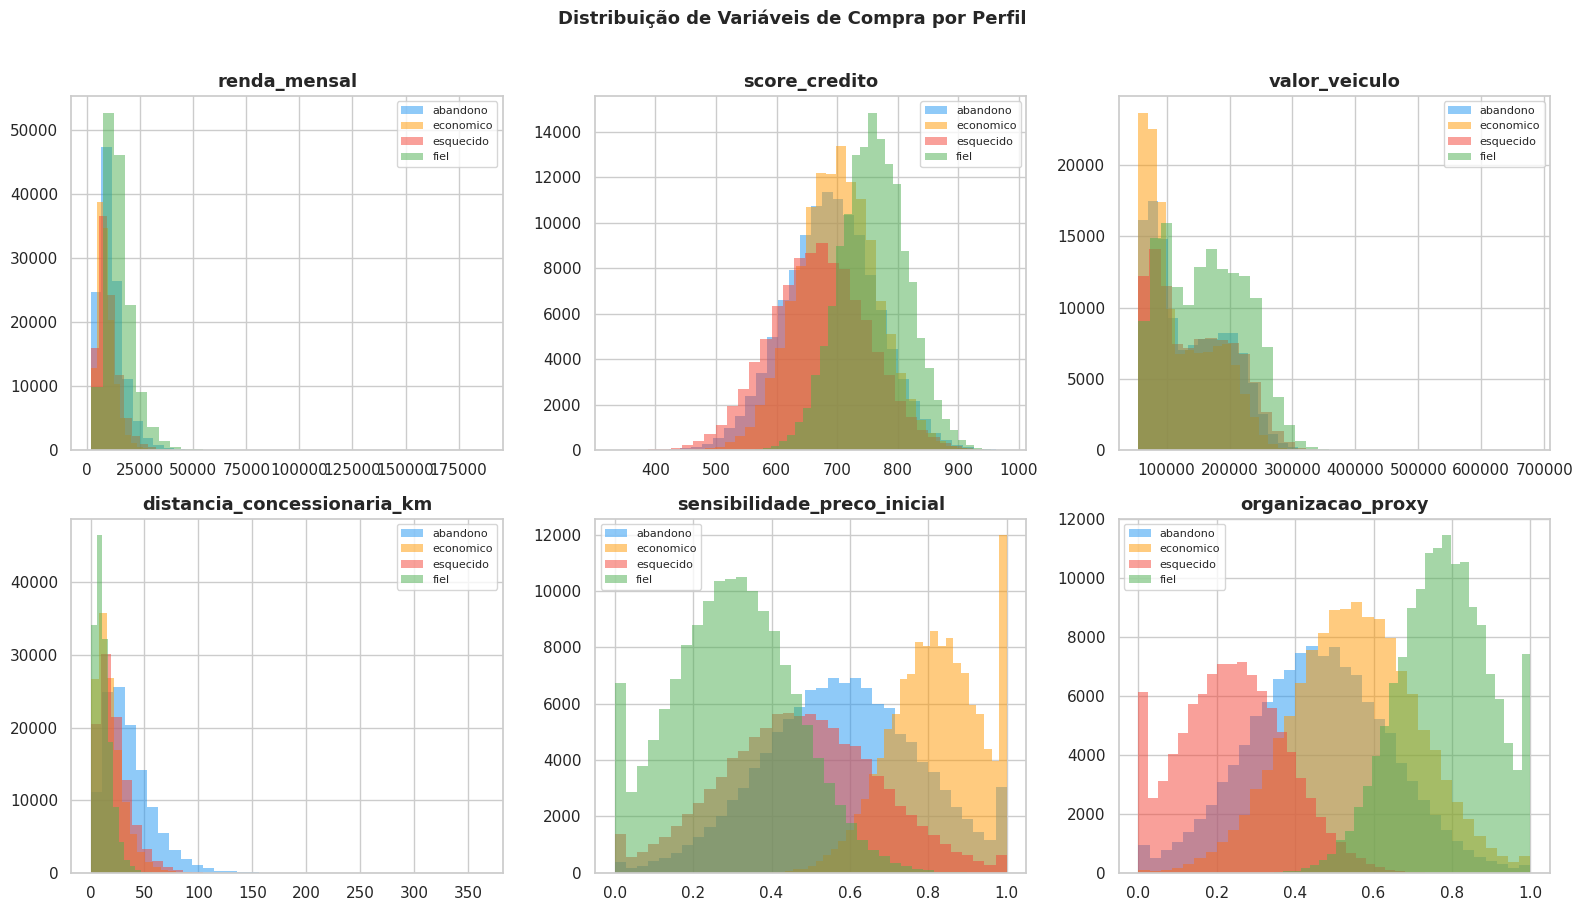

In [ ]:
# Boxplots variáveis de compra por perfil
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
key_purchase = ['renda_mensal','score_credito','valor_veiculo',
                'distancia_concessionaria_km','sensibilidade_preco_inicial','organizacao_proxy']
colors_profile = {'fiel':'#4CAF50','economico':'#FF9800','abandono':'#2196F3','esquecido':'#F44336'}

for i, var in enumerate(key_purchase):
    for perfil, grp in df.groupby('perfil_latente'):
        axes[i].hist(grp[var].dropna(), bins=35, alpha=0.5, label=perfil,
                     color=colors_profile[perfil], edgecolor='none')
    axes[i].set_title(var)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição de Variáveis de Compra por Perfil', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_purchase_by_profile.png', dpi=110, bbox_inches='tight')
plt.show()


In [ ]:
# Médias do momento da compra por perfil
purchase_num = ['idade','renda_mensal','score_credito','distancia_concessionaria_km',
                'km_estimado_mes','sensibilidade_preco_inicial','organizacao_proxy',
                'tempo_decisao_dias','entrada_pct','prazo_financiamento_meses',
                'prestacao_renda_ratio','garantia_estendida','plano_manutencao',
                'aceitou_marketing','compra_a_vista','valor_veiculo']

purchase_means = df.groupby('perfil_latente')[purchase_num].mean().round(3)
print("Médias das variáveis do momento da compra por perfil:")
purchase_means


Médias das variáveis do momento da compra por perfil:


,idade,renda_mensal,score_credito,distancia_concessionaria_km,km_estimado_mes,sensibilidade_preco_inicial,organizacao_proxy,tempo_decisao_dias,entrada_pct,prazo_financiamento_meses,prestacao_renda_ratio,garantia_estendida,plano_manutencao,aceitou_marketing,compra_a_vista,valor_veiculo
perfil_latente,,,,,,,,,,,,,,,,
abandono,39.158,11431.001,690.072,35.114,1710.376,0.579,0.460,11.250,0.505,34.299,0.168,0.141,0.016,0.421,0.365,136065.050
economico,42.087,8906.235,699.905,18.073,1607.751,0.817,0.550,24.054,0.462,39.331,0.172,0.214,0.113,0.557,0.344,120898.193
esquecido,36.059,10177.539,670.082,22.179,1910.628,0.471,0.243,15.107,0.469,37.094,0.202,0.235,0.066,0.458,0.336,144345.791
fiel,46.957,14868.966,760.159,11.564,1457.772,0.302,0.778,17.049,0.622,21.776,0.178,0.569,0.436,0.575,0.427,163218.149


## 8. Verificações de Qualidade e Consistência

In [ ]:
print("VERIFICAÇÕES DE CONSISTÊNCIA \n")

# 1. Compra à vista vs prazo
cv_com_prazo = ((df['compra_a_vista'] == 1) & (df['prazo_financiamento_meses'] > 0)).sum()
nao_cv_prazo0 = ((df['compra_a_vista'] == 0) & (df['prazo_financiamento_meses'] == 0)).sum()
print(f"Compra à vista com prazo > 0 (inconsistência lógica): {cv_com_prazo}")
print(f"Não à vista com prazo = 0 (330 casos — à vista registrado como 0): {nao_cv_prazo0}")
print("  → Decisão: 330 casos com compra_a_vista=0 e prazo=0 serão recategorizados como à vista.\n")

# 2. Prestação/renda > 1
ratio_above_1 = (df['prestacao_renda_ratio'] > 1.0).sum()
print(f"Prestação/renda > 1.0 (comprometimento > 100%): {ratio_above_1:,} ({ratio_above_1/len(df)*100:.2f}%)")
print("  → Decisão: Valores plausíveis para o contexto brasileiro (renda subnotificada); manter, aplicar winsorização suave.\n")

# 3. Distância 0
dist_zero = (df['distancia_concessionaria_km'] <= 0).sum()
print(f"Distância <= 0 km: {dist_zero}")
print("  → Decisão: Distância 0 pode indicar dados no mesmo CEP; manter.\n")

# 4. Outliers via IQR
print("Outliers por IQR (1.5x):")
for col in ['renda_mensal','valor_veiculo','distancia_concessionaria_km','km_estimado_mes','gasto_manutencao_rede_24m']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n:,} outliers ({100*n/df[col].count():.1f}%)")
print("  → Decisão: Aplicar winsorização no percentil 1%-99% para variáveis contínuas de alta dispersão.")


=== VERIFICAÇÕES DE CONSISTÊNCIA ===

Compra à vista com prazo > 0 (inconsistência lógica): 0
Não à vista com prazo = 0 (330 casos — à vista registrado como 0): 330
  → Decisão: 330 casos com compra_a_vista=0 e prazo=0 serão recategorizados como à vista.

Prestação/renda > 1.0 (comprometimento > 100%): 5,305 (1.06%)
  → Decisão: Valores plausíveis para o contexto brasileiro (renda subnotificada); manter, aplicar winsorização suave.

Distância <= 0 km: 0
  → Decisão: Distância 0 pode indicar dados no mesmo CEP; manter.

Outliers por IQR (1.5x):
  renda_mensal: 17,480 outliers (3.6%)
  valor_veiculo: 345 outliers (0.1%)
  distancia_concessionaria_km: 23,734 outliers (4.8%)
  km_estimado_mes: 6,025 outliers (1.2%)
  gasto_manutencao_rede_24m: 11,068 outliers (2.2%)
  → Decisão: Aplicar winsorização no percentil 1%-99% para variáveis contínuas de alta dispersão.


## 9. Tratamento de Dados

### Justificativa

| Problema | Decisão | Justificativa |
|---|---|---|
| Valores nulos (< 3%) | Imputação pela mediana | Robusta a outliers; taxa baixa não distorce distribuição |
| Compra à vista mal codificada | Corrigir flag | Consistência lógica |
| Outliers em variáveis contínuas | Winsorização 1%–99% | Preserva a distribuição real, elimina extremos  |
| Variáveis categóricas | One-Hot Encoding | Compatibilidade com algoritmos de clustering baseados em distância |
| Escalas heterogêneas | StandardScaler | K-Means e algoritmos similares são sensíveis à escala |


In [ ]:
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

# 1. Corrigir compra_a_vista
mask_fix = (df_clean['compra_a_vista'] == 0) & (df_clean['prazo_financiamento_meses'] == 0)
df_clean.loc[mask_fix, 'compra_a_vista'] = 1
print(f"Corrigidos {mask_fix.sum()} registros de compra_a_vista.")

# 2. Imputar nulos — mediana para variáveis numéricas
null_cols = df_clean[PURCHASE_VARS + BEHAVIORAL_VARS].isnull().sum()
null_cols = null_cols[null_cols > 0].index.tolist()
for col in null_cols:
    if df_clean[col].dtype in ['float64', 'int64']:
        med = df_clean[col].median()
        df_clean[col].fillna(med, inplace=True)
print(f"Imputados por mediana: {null_cols}")
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")


Corrigidos 330 registros de compra_a_vista.
Imputados por mediana: ['idade', 'renda_mensal', 'score_credito', 'teve_ford_antes', 'distancia_concessionaria_km', 'garantia_estendida', 'plano_manutencao', 'aceitou_marketing', 'tempo_decisao_dias', 'share_revisoes_rede_24m', 'gasto_manutencao_rede_24m', 'satisfacao_marca_24m']
Nulos restantes: 0


In [ ]:
# 3. Winsorização (1%-99%) para variáveis contínuas de alta dispersão
winsor_cols = ['renda_mensal', 'valor_veiculo', 'distancia_concessionaria_km',
               'km_estimado_mes', 'gasto_manutencao_rede_24m', 'meses_ate_primeira_revisao',
               'sensibilidade_desconto_pos', 'share_revisoes_rede_24m', 'satisfacao_marca_24m']

for col in winsor_cols:
    lo, hi = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

print("Winsorização aplicada às colunas:", winsor_cols)


Winsorização aplicada às colunas: ['renda_mensal', 'valor_veiculo', 'distancia_concessionaria_km', 'km_estimado_mes', 'gasto_manutencao_rede_24m', 'meses_ate_primeira_revisao', 'sensibilidade_desconto_pos', 'share_revisoes_rede_24m', 'satisfacao_marca_24m']


In [ ]:
# 4. One-Hot Encoding das categóricas
cat_purchase = ['regiao', 'uso_principal', 'canal_compra', 'categoria_veiculo', 'modelo_veiculo']

df_encoded = pd.get_dummies(df_clean, columns=cat_purchase, drop_first=True, dtype=float)
print(f"Shape após encoding: {df_encoded.shape}")
print("Novas colunas categóricas:", [c for c in df_encoded.columns if any(c.startswith(p+'_') for p in cat_purchase)])


Shape após encoding: (500000, 58)
Novas colunas categóricas: ['regiao_interior', 'regiao_metropolitana', 'uso_principal_familia', 'uso_principal_lazer', 'uso_principal_misto', 'uso_principal_trabalho', 'canal_compra_loja', 'canal_compra_online', 'canal_compra_telefone', 'categoria_veiculo_picape', 'categoria_veiculo_sedan', 'categoria_veiculo_suv', 'categoria_veiculo_van', 'modelo_veiculo_Edge', 'modelo_veiculo_F-150', 'modelo_veiculo_Fiesta', 'modelo_veiculo_Fiesta Sedan', 'modelo_veiculo_Focus Hatch', 'modelo_veiculo_Fusion', 'modelo_veiculo_Ka', 'modelo_veiculo_Ka Sedan', 'modelo_veiculo_Maverick', 'modelo_veiculo_Ranger', 'modelo_veiculo_Territory', 'modelo_veiculo_Transit', 'modelo_veiculo_Transit Minibus']


In [ ]:
# 5. Separar features de clustering

CLUSTERING_FEATURES = BEHAVIORAL_VARS.copy()

X_cluster = df_encoded[CLUSTERING_FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTERING_FEATURES, index=df_encoded.index)

print("Features selecionadas para clustering:")
for f in CLUSTERING_FEATURES:
    print(f"  • {f}")
print(f"\nShape de X para clustering: {X_scaled_df.shape}")


Features selecionadas para clustering:
  • fez_primeira_revisao_rede
  • meses_ate_primeira_revisao
  • perdeu_primeira_revisao
  • voltou_tarde_revoltado
  • trouxe_oleo_externo
  • pede_desconto_revisao
  • sensibilidade_desconto_pos
  • qtde_revisoes_24m
  • share_revisoes_rede_24m
  • gasto_manutencao_rede_24m
  • satisfacao_marca_24m
  • churn_rede_24m

Shape de X para clustering: (500000, 12)


## 10. Matriz de Correlação

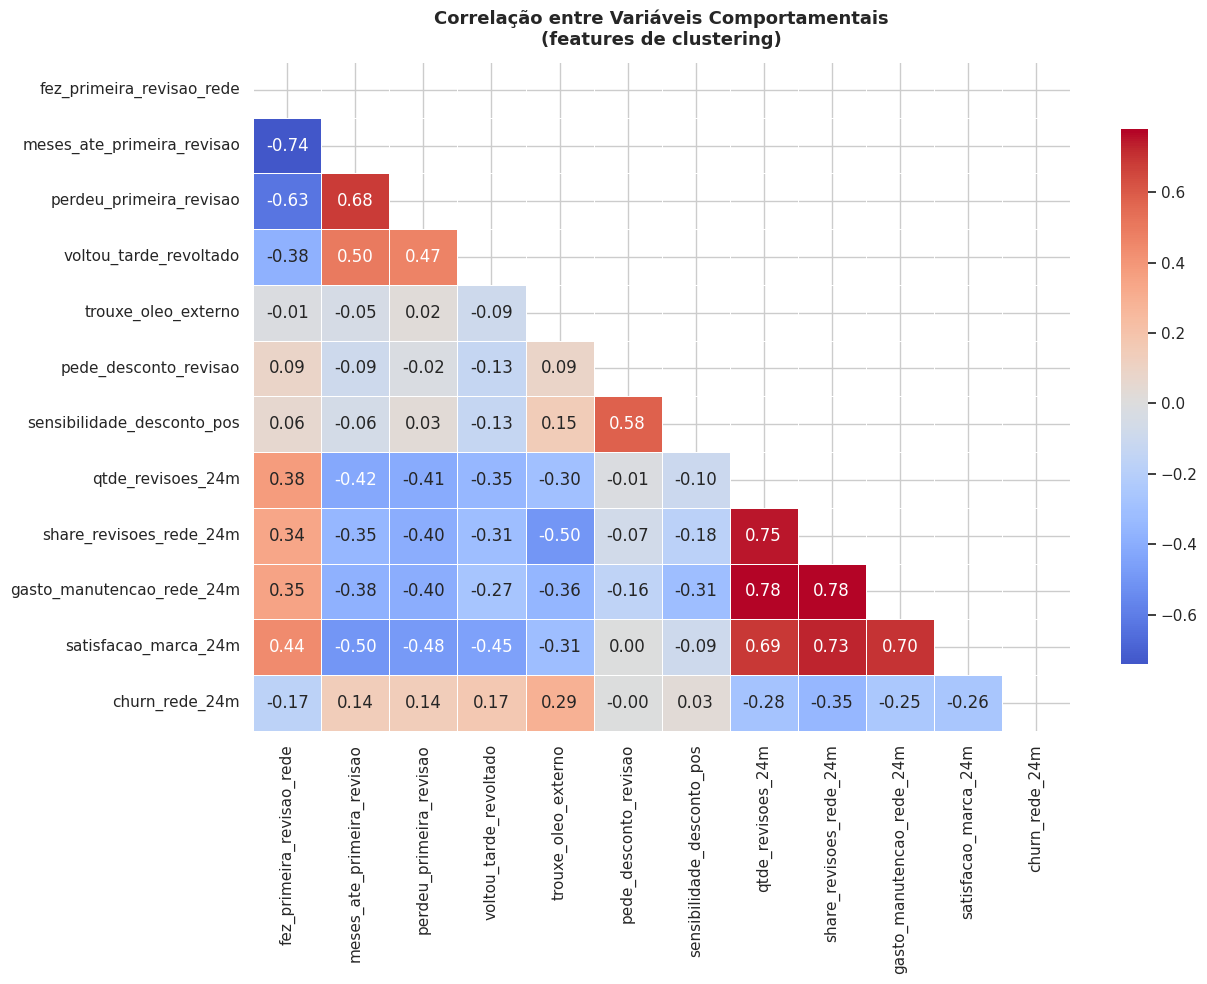

In [ ]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = X_cluster.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlação entre Variáveis Comportamentais\n(features de clustering)', pad=12)
plt.tight_layout()
plt.savefig('plot_corr_cluster.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Síntese

### Sobre a qualidade dos dados
- **500.000 registros** com apenas **0,4% de nulos** — excelente qualidade para um dataset de escala.
- 12 colunas com valores ausentes, todos com taxa < 2,5%. Imputação por mediana é adequada.
- Inconsistência identificada e corrigida: 330 registros com `compra_a_vista=0` e `prazo=0`.
- Outliers presentes em `renda_mensal` (3,6%) e `distancia_concessionaria_km` (4,8%) — tratados por winsorização.

### Validação parcial das hipóteses do gerente
As hipóteses de negócio levantadas pelo gerente encontram forte suporte nos dados:
- **Fiel**: altamente ativo, raramente churna, alta satisfação → ✅ confirmado
- **Abandono**: realiza poucas revisões, alto uso de óleo externo, baixo gasto na rede → ✅ confirmado
- **Esquecido**: 90% perdeu a primeira revisão, voltou tarde, baixa satisfação → ✅ confirmado
- **Econômico**: mantém presença na rede mas com alta sensibilidade a desconto pós-venda (0.86) → ✅ confirmado